## 순환 신경망(RNN)

* 지금까지는 피드포워드 신경망
    * 피드포워드: 흐름이 단방향인 신경망

    -> 시계열 데이터를 잘 다루지 못함(시계열 데이터의 성질을 충분히 학습할 수 없음)  
    => 순환 신경망

### 확률과 언어 모델

#### word2vec을 확률 관점에서 바라보다
* CBOW 모델은 사후 확률을 모델링
* CBOW 모델의 학습으로 수행하는 일은 손실 함수를 최소화하는 가중치 매개변수를 찾는 것
* CBOW 모델은 맥락으로부터 타깃을 더 정확하게 추측할 수 있음  
=> 단어의 의미가 인코딩된 단어의 분산 표현을 얻을 수 있음

#### 언어 모델
* 언어 모델은 단어 나열에 확률을 부여
* 특정한 단어의 시퀀스에 대해 그 시퀀스가 일어날 가능성이 어느 정도인지 (얼마나 자연스러운 단어 순서인지)를 확률로 평가

* 언어 모델은 다양하게 응용 가능
    * 기계 번역
    * 음성 인식
        * 사람의 음성으로부터 몇 개의 문장 후보를 생성
        * 언어 모델을 사용해 후보 문장으로써 자연스러운지를 기준으로 순서를 매김
    * 새로운 문장 생성
        * 언어 모델은 단어 순서의 자연스러움을 확률적으로 평가할 수 있음  
            => 확률분포에 따라 다음으로 적합한 단어를 샘플링할 수 있음

* 언어 모델 수식
    * $w_1, ..., w_m$ 이라는 m개 단어로 된 문장
    * 단어가 $w_1, ..., w_m$ 순서로 출현할 확률을 $P(w_1, ..., w_m)$
        * 확률은 여러 사건이 동시에 일어날 확률이므로 동시 확률
    * 동시 확률은 사후 확률을 사용해 분해 가능
    $$
    P(w_1, ..., w_m) = P(w_m|w_1,...,w_{m-1})P(w_{m-1}|w_1,...,w_{m-2}) \\
    ...P(w_3|w_1,w_2)P(w_2|w_1)P(w_1) \\
    = \prod_{t=1}^m P(w_t|w_1,...,w_{t-1})
    $$
    * $\prod$ 기호는 모든 원소를 곱하는 총곱
    * 사후 확률은 타깃 단어보다 왼쪽에 있는 모든 단어를 맥락으로 했을 때의 확률
* 목표는 $P(w_t|w_1,...,w_{t-1})$ 확률을 구하는 것  
    => 이로부터 $P(w_1, ..., w_m)$를 구할 수 있음
* $P(w_t|w_1,...,w_{t-1})$을 나타내는 모델은 조건부 언어 모델

#### CBOW 모델을 언어 모델로?
* 맥락의 크기를 특정값으로 한정하여 근사적으로 나타낼 수 있음
$$
P(w_1, ..., w_m) = \prod_{t=1}^m P(w_t|w_1,...,w_{t-1}) \approx \prod_{t=1}^m P(w_t|w_{t-2},w_{t-1})
$$

* 마르코프 연쇄 또는 마르코프 모델
    * 미래의 상태가 현재 상태에만 의존해 결정되는 것
    * 그 직전 N개의 사건에만 의존할 때, N층 마르코프 연쇄  
    => 2층 마르코프 연쇄로 볼 수 있음

* 맥락의 크기는 임의로 설정할 수 있으나 결국 특정 길이로 고정  
* CBOW는 맥락의 크기를 얼마든지 키울 수 있으나 맥락 안의 단어 순서가 무시되는 한계가 있음
    * CBOW = continuous bag-of-words -> 가방 속의 단어 순서는 무시

* 이상적으로는 맥락의 단어 순서도 고려한 모델이 바람직함
* 단어 벡터를 은닉층에서 연결하는 방식을 생각할 수 있음  
    -> 맥락의 크기에 비례해 가중치 매개변수도 늘어남

=> RNN

* RNN은 맥락이 아무리 길더라도 그 맥락의 정보를 기억하는 메커니즘을 갖춤
* RNN 사용 시 긴 시계열 데이터에도 대응 가능

### RNN이란
* Recurrent는 순환한다 등으로 번역
* 즉 RNN은 순환하는 신경망
    * Recursive NN도 있음 -> 트리 구조의 데이터를 처리하기 위한 신경망으로 순환 신경망과는 다름

#### 순환하는 신경망
* 순환하기 위해서는 닫힌 경로가 필요함
* 닫힌 경로 또는 순환하는 경로가 존재해야 데이터가 같은 장소를 반복해 왕래할 수 있음
* 순환 경로를 따라 데이터는 끊임없이 순환하고 과거의 정보를 기억하는 동시에 최신 데이터로 갱신될 수 있음

* $x_t$를 입력받으며 t는 시간
    * 시계열 데이터 ($x_0, x_1, ..., x_t, ...$)가 RNN 계층에 입력됨
* 출력은 ($h_0, h_1, ..., h_t, ...$)
* 각 시각에 입력되는 $x_t$는 벡터라고 가정하면 각 단어의 분산 표현이 $x_t$가 되며 분산 표현이 하나씩 RNN 계층에 입력

#### 순환 구조 펼치기
* 순환구조를 펼치면 친숙한 신경망이 됨 -> 피드포워드 신경망과 같은 구조
* 다만 다수의 계층 모두가 실제로는 같은 계층인 것이 다름

* 각 시각의 계층은 그 계층으로부터의 입력과 1개 전의 RNN 계층으로부터의 출력을 받음
$$
h_t = tanh(h_{t-1}W_h + x_t W_x + b)
$$
* $W_x$: 입력 x를 출력 h로 변환하기 위한 가중치
* $W_h$: 1개의 RNN 출력을 다음 시각의 출력으로 변환하기 위한 가중치
* $h_t$: 다른 계층을 향해 출력 + 다음 시각의 RNN 계층을 향해 출력
* 출력 $h_t$는 한 시각 이전 출력 $h_{t-1}$에 기초해 계산
    * RNN은 h라는 상태를 가지고 있으며 위의 식 형태로 갱신  
    => 상태를 가지는 계층 혹은 메모리가 있는 계층
* $h_t$를 은닉 상태 혹은 은닉 상태 벡터라고 함

#### BPTT
* RNN 계층은 가로로 펼친 신경망으로 간주할 수 있음
* 순환 구조를 펼친 후의 RNN에는 일반적인 오차역전파법을 적용할 수 있음
* 먼저 순전파를 수행하고, 이어서 역전파를 수행하여 원하는 기울기를 구할 수 있음  
    => 여기서의 오차역전파법은 BPTT라 함

* BPTT를 이용하면 RNN을 학습할 수 있을 것으로 보이나 긴 시계열 데이터를 학습할 때 문제
    * 시계열 데이터의 시간 크기가 커지는 것에 비례해 BPTT가 소비하는 컴퓨팅 자원도 증가
    * 시간 크기가 커지면 역전파 시의 기울기가 불안정해지는 문제

#### Truncated BPTT
* 큰 시계열 데이터를 취급할 때는 신경망 연결을 적당한 길이로 끊음
* 잘라낸 작은 신경망에서 오차역전파법을 수행  
    => Truncated BPTT

* Truncated BPTT를 제대로 구현하려면 역전파의 연결만 끊어야 함
* 역전파의 연결은 적당한 길이로 잘라내, 잘라낸 신경망 단위로 학습을 수행

#### Truncate BPTT의 미니배치 학습
* 미니배치 학습을 수행하기에 구체적인 배치 방식을 고려해 데이터를 순서대로 입력해야 함  
    => 데이터를 주는 시작 위치를 각 미니배치의 시작 위치로 옮겨줘야 함
* 길이가 1000인 시계열 데이터에 대해 시각의 길이를 10개 단위로 잘라 Truncated BPTT로 학습하는 경우
    * 미니배치의 수를 두 개로 구성해 학습하려면
        * RNN 계층의 입력 데이터로, 첫 번째 미니배치 때는 처음부터 순서대로 데이터를 제공
        * 두 번째 미니배치 때는 500번째의 데이터를 시작 위치로 정하고 그 위치부터 다시 순서대로 데이터를 제공

### RNN 구현
* Truncated BPTT 방식의 학습을 따른다면 가로 크기가 일정한 일련의 신경망을 만들면 됨
    * 길이가 T인 시계열 데이터를 받고 각 시각의 은닉 상태를 T개 출력
    * 옆으로 성장한 신경망을 하나의 계층으로 구현
        * 상하 방향의 입력과 출력을 각각 하나로 묶으면 옆으로 늘어선 일련의 계층을 하나의 계층으로 간주할 수 있음  
    
    => Time RNN 계층 내에서 한 단계의 작업을 수행하는 계층을 RNN 계층, T개 단계분의 작업을 한꺼번에 처리하는 계층을 Time RNN 계층

#### RNN 계층 구현
$$
h_t = tanh(h_{t-1}W_h + x_t W_x + b)
$$
* 여기서 데이터를 미니배치로 모아 처리
    * $x_t$, $h_t$는 샘플 데이터를 행 방향에 저장
    * 미니배치 크기가 N, 입력 벡터의 차원 수가 D, 은닉 상태 벡터의 차원 수가 H

In [1]:
import numpy as np

In [7]:
class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None
    
    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = np.matmul(h_prev, Wh) + np.matmul(x, Wx) + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache

        dt = dh_next * (1 - h_next ** 2)
        db = np.sum(dt, axis=0)
        dWh = np.matmul(h_prev.T, dt)
        dh_prev = np.matmul(dt, Wh.T)
        dWx = np.matmul(x.T, dt)
        dx = np.matmul(dt, Wx.T)

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev

#### Time RNN 계층 구현
* T개의 RNN 계층으로 구현
* RNN 계층의 은닉 상태 h를 인스턴스 변수로 유지
* 은닉 상태를 인계받는 용도
    * Time RNN 사용자는 RNN 계층 사이에서 은닉 상태를 인계하는 작업을 생각하지 않아도 됨!  
    => stateful 인수로 조정

In [ ]:
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self):
        self.h = None

* layers: 다수의 RNN 계층을 리스트로 저장
* h: forward() 호출 시 마지막 RNN 상태를 저장
* dh: backward() 호출 시 하나 앞 블록의 은닉 상태의 기울기를 저장

In [9]:
def forward(self, xs):
    Wx, Wh, b = self.params
    N, T, D = xs.shape
    D, H = Wx.shape
    
    self.layers = []
    hs = np.empty((N, T, H), dtype='f')

    if not self.stateful or self.h is None:
        self.h = np.zeros((N, H), dtype='f')
    
    for t in range(T):
        layer = RNN(*self.params)
        self.h = layer.forward(xs[:, t, :], self.h)
        hs[:, t, :] = self.h
        self.layers.append(layer)

    return hs

* 입력 xs를 받음
    * xs: T개 분량의 시계열 데이터
* 미니배치 크기 N, 입력 벡터 차원수 D -> xs의 형상 = (N, T, D)
* RNN 계층의 은닉 상태 h는 처음 호출 시 원소가 모두 0인 영행렬로 초기화
    * 인스턴스 변수 stateful이 False일 경우도 마찬가지
* hs = empty((N, T, H), dtype='f') 문장에서 출력값을 담을 그릇 hs를 준비
* T회 반복되는 for문에서 RNN 계층을 생성하여 인스턴스 변수 layers에 추가
* RNN 계층이 각 시각 t의 은닉 상태 h를 계산하고, 이를 hs에 해당 인덱스의 값으로 설정

In [11]:
def backward(self, dhs):
    Wx, Wh, b = self.params
    N, T, H = dhs.shape
    D, H = Wx.shape
    
    dxs = np.empty((N, T, D), dtype='f')
    dh = 0
    grads = [0, 0, 0]
    for t in reversed(range(T)):
        layer = self.layers[t]
        dx, dh = layer.backward(dhs[:, t, :] + dh)
        dxs[:, t, :] = dx

        for i, grad in enumerate(layer.grads):
            grads[i] += grad
        
    for i, grad in enumerate(grads):
        self.grads[i][...] = grad
    self.dh = dh

    return dxs

* dhs: 상류에서부터 전해지는 기울기
* dxs: 하류로 내보내는 기울기
* Truncated BPTT를 수행하기 때문에 이 블록의 이전 시각 역전파는 필요하지 않음
* 이전 시각의 은닉 상태 기울기는 dh에 저장

* t번째 RNN 계층에서는 위로부터의 기울기 $dh_t$와 한 시각 뒤 계층으로부터의 기울기 $dh_{next}$가 전해짐
* 역전파 시 RNN 계층에는 합산된 기울기 $dh_t + dh_{next}$가 입력

### 시계열 데이터 처리 계층 구현
* RNN을 사용하는 언어 모델 RNN Language Model, RNNLM

#### RNNLM의 전체 그림
* 가장 아래 층은 Embedding 계층
    * 단어 ID를 분산 표현으로 변환, 분산 표현이 RNN 계층으로 입력
* RNN 계층은 은닉 상태를 다음 층으로 출력함과 동시에 다음 시각의 RNN 계층으로 출력
* RNN 계층이 위로 출력한 은닉 상태는 Affine 계층을 거쳐 Softmax 계층으로 전달
* RNNLM은 지금까지 입력된 단어를 기억하고 그것을 바탕으로 다음에 출현할 단어를 예측  
=> RNN 계층이 과거에서 현재로 데이터를 계속 흘려보내줌으로써 과거의 정보를 인코딩해 저장할 수 있는 것

#### Time 계층 구현
* 시계열 데이터를 한꺼번에 처리하는 계층을 Time Embedding, Time Affine 형태로 구현
* Time Affine 계층은 단순히 Affine 계층 T개를 이용하는 방식 대신 행렬 계산으로 한꺼번에 처리

* 시계열에서의 Softmax 계층을 구현할 때는 손실 오차를 구하는 Cross Entropy Eror 계층도 함께 구현  
    => Time Softmax with Loss 계층으로 구현
* $x_0$, $x_1$ 등의 데이터는 아래층에서부터 전해지는 점수
* $t_9$, $t_1$ 등의 데이터는 정답 레이블
* T개의 Softmax with Loss 계층 각각이 손실을 산출, 손실들을 합산해 평균한 값이 최종 손실
$$
L = \frac{1}{T}(L_0 + L_1 + ... + L_{T-1})
$$

### RNNLM 학습과 평가

#### RNNLM 구현

In [12]:
import sys
sys.path.append('..')
import numpy as np
from common.time_layers import *

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

* Affine 계층에서 Xavier 초깃값을 이용
    * Xavier 초깃값: 이전 계층의 노드가 n개라면 표준편차가 $\frac{1}{\sqrt n}$인 분포들로 초기화

In [14]:
def forward(self, xs, ts):
    for layer in self.layers:
        xs = layer.forward(xs)
    loss = self.loss_layer.forward(xs, ts)
    return loss

def backward(self, dout=1):
    dout = self.loss_layer.backward(dout)
    for layer in reversed(self.layers):
        dout = layer.backward(dout)
    return dout

def reset_state(self):
    self.rnn_layer.reset_state()

#### 언어 모델의 평가
* 언어 모델은 주어진 과거 단어로부터 다음에 출현할 단어의 확률분포를 출력
* 언어 모델의 예측 성능을 평가하는 척도로 퍼플렉서티(혼란도)를 자주 이용
    * 확률의 역수
    * 작을수록 좋으며 분기 수로 해석 가능
        * 1.25면 다음에 출현할 수 있는 단어의 후보를 1개 정도로 좁혔음
        * 5일 경우 후보가 아직 5개

* 입력 데이터가 여러 개일 경우
$$
L = -\frac{1}{N} \sum_n \sum_k t_{nk} \log y_{nk}
$$
$$
\text{perplexity} = e^L
$$
* N: 데이터의 총개수
* $t_n$: 원핫 벡터로 나타낸 정답 레이블, $t_{nk}$는 n개째 데이터의 k번째 값을 의미
* $y_{nk}$: 확률분포 (신경망에서는 Softmax 출력)
* L: 신경망의 손실, 교차 엔트로피 오차와 같은 식

#### RNNLM의 학습 코드

In [16]:
import sys
sys.path.append('..')
import numpy as np
from common.time_layers import *

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()

말뭉치 크기: 1000, 어휘 수: 418
| 에폭 1 | 퍼플렉서티 401.49
| 에폭 2 | 퍼플렉서티 287.76
| 에폭 3 | 퍼플렉서티 231.82
| 에폭 4 | 퍼플렉서티 219.75
| 에폭 5 | 퍼플렉서티 207.38
| 에폭 6 | 퍼플렉서티 204.23
| 에폭 7 | 퍼플렉서티 199.66
| 에폭 8 | 퍼플렉서티 196.91
| 에폭 9 | 퍼플렉서티 191.45
| 에폭 10 | 퍼플렉서티 193.57
| 에폭 11 | 퍼플렉서티 189.29
| 에폭 12 | 퍼플렉서티 192.54
| 에폭 13 | 퍼플렉서티 189.84
| 에폭 14 | 퍼플렉서티 189.92
| 에폭 15 | 퍼플렉서티 189.72
| 에폭 16 | 퍼플렉서티 186.88
| 에폭 17 | 퍼플렉서티 184.14
| 에폭 18 | 퍼플렉서티 180.51
| 에폭 19 | 퍼플렉서티 181.68
| 에폭 20 | 퍼플렉서티 184.11
| 에폭 21 | 퍼플렉서티 181.00
| 에폭 22 | 퍼플렉서티 176.29
| 에폭 23 | 퍼플렉서티 175.15
| 에폭 24 | 퍼플렉서티 176.94
| 에폭 25 | 퍼플렉서티 176.22
| 에폭 26 | 퍼플렉서티 174.11
| 에폭 27 | 퍼플렉서티 168.55
| 에폭 28 | 퍼플렉서티 166.22
| 에폭 29 | 퍼플렉서티 164.23
| 에폭 30 | 퍼플렉서티 160.28
| 에폭 31 | 퍼플렉서티 162.44
| 에폭 32 | 퍼플렉서티 155.48
| 에폭 33 | 퍼플렉서티 154.38
| 에폭 34 | 퍼플렉서티 150.71
| 에폭 35 | 퍼플렉서티 149.04
| 에폭 36 | 퍼플렉서티 144.26
| 에폭 37 | 퍼플렉서티 138.37
| 에폭 38 | 퍼플렉서티 136.33
| 에폭 39 | 퍼플렉서티 129.73
| 에폭 40 | 퍼플렉서티 124.51
| 에폭 41 | 퍼플렉서티 123.98
| 에폭 42 | 퍼플렉서티 117.20
| 에폭 43 | 퍼플렉서티 112

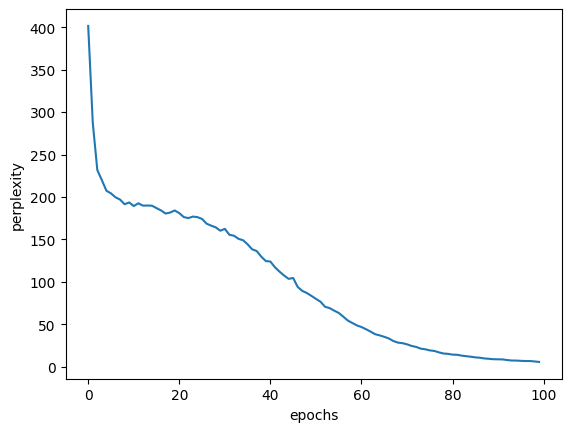

In [17]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
from common.optimizer import SGD
from dataset import ptb

# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100 # RNN의 은닉 상태 벡터의 원소 수
time_size = 5     # Truncated BPTT가 한 번에 펼치는 시간 크기
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기(전체 중 1000개만)
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # 입력
ts = corpus[1:]   # 출력(정답 레이블)
data_size = len(xs)
print('말뭉치 크기: %d, 어휘 수: %d' % (corpus_size, vocab_size))

# 학습 시 사용하는 변수
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# 미니배치의 각 샘플의 읽기 시작 위치를 계산
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # 미니배치 취득
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        # 기울기를 구하여 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # 에폭마다 퍼플렉서티 평가
    ppl = np.exp(total_loss / loss_count)
    print('| 에폭 %d | 퍼플렉서티 %.2f'
          % (epoch+1, ppl))
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0

# 그래프 그리기
x = np.arange(len(ppl_list))
plt.plot(x, ppl_list, label='train')
plt.xlabel('epochs')
plt.ylabel('perplexity')
plt.show()

* 데이터 제공 방법
    * Truncated BPTT 방식으로 학습 수행 -> 데이터는 순차적으로 주고 각각의 미니배치에서 데이터를 읽는 시작 위치를 조정해야 함
    1. 각 미니배치에서 데이터를 읽기 시작하는 위치를 계싼해 offsets에 저장
    2. 데이터를 순차적으로 읽음
        * batch_x, batch_t를 준비
        * time_idx를 1씩 늘리면서, 말뭉치에서 time_idx 위치의 데이터를 얻음
        * 1에서 계산한 offsets를 이용해 각 미니배치에서 오프셋을 추가
        * 말뭉치를 읽는 위치가 말뭉치 크기를 넘어설 경우 말뭉치의 처음으로 돌아와야 하는데 말뭉치의 크기로 나눈 나머지를 인덱스로 사용
    3. 에폭마다 퍼플렉서티를 구하기 위해 에폭마다 손실의 평균을 구하고 그 값을 사용해 퍼플렉서티를 구함

* 결과에서는 퍼플렉서티가 순조롭게 감소  
    => 큰 말뭉치에서는 전혀 대응할 수 없음

#### RNNLM의 Trainer 클래스
1. RnnlmTrainer 클래스에 model과 optimzer를 주어 초기화
2. fit() 메서드를 호출해 학습을 수행
    1. 미니배치를 순차적으로 만들음
    2. 모델의 순전파 및 역전파 호출
    3. 옵티마이저로 가중치 갱신
    4. 퍼플렉서티를 구함